# Laboratorio final

**Fecha de entrega:** 09 de Julio a las 16h  
**Grupos:** 4 estudiantes  
**Integrantes:**
- García Avalos Alan Nicolas
- Espinoza Picon Diego Steven Martin
- Castro Contreras Luis Alejandro

**Dataset:** `dataset_train.csv`

## Contexto

Una empresa de servicios financieros desea clasificar automáticamente a sus clientes en tres segmentos de comportamiento (`Clase`) para personalizar campañas comerciales.

El dataset contiene información de **1 600 clientes** y presenta varios problemas comunes en proyectos reales de Machine Learning:

- columnas con valores únicos por fila;
- variables categóricas nominales;
- variables categóricas ordinales;
- variables numéricas;
- variables con escalas muy diferentes;
- alta correlación positiva entre algunas variables;
- correlación negativa entre otras variables.

El objetivo del laboratorio es construir un **pipeline completo de clasificación**, comparar modelos mediante validación cruzada, guardar el mejor modelo y evaluarlo en un conjunto de test (`dataset_test.csv`).

## Variables disponibles

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador único del cliente. |
| `region` | Región donde reside el cliente. |
| `experiencia_digital` | Nivel de experiencia digital. |
| `satisfaccion_servicio` | Nivel de satisfacción del cliente. |
| `ingreso_anual_soles` | Ingreso anual del cliente. |
| `gasto_mensual_soles` | Gasto mensual promedio. |
| `ratio_deuda` | Relación entre deuda e ingresos. |
| `indice_ahorro` | Índice de ahorro del cliente. |
| `Clase` | Segmento del cliente (objetivo) |

# Reglas del laboratorio

1. No está permitido modificar la variable objetivo `Clase`.
2. No está permitido evaluar el modelo final sobre el conjunto de entrenamiento.
3. Todo preprocesamiento debe estar dentro de un `Pipeline` o `ColumnTransformer`.
4. Todos los modelos deben evaluarse con las mismas particiones de Cross Validation.
5. El modelo final debe guardarse y luego cargarse para evaluar el conjunto de test.

# Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Puede agregar más ...

import joblib

# Carga del dataset

In [2]:
df = pd.read_csv("Data/dataset_train.csv")
df.head()

,cliente_id,region,experiencia_digital,satisfaccion_servicio,ingreso_anual_soles,gasto_mensual_soles,ratio_deuda,indice_ahorro,clase
0,CLI-01728,Junín,Bajo,Alta,35235.60,1819.16,0.0200,0.8224,Clase_B_riesgo_medio
1,CLI-00982,La Libertad,Bajo,Baja,42260.47,2441.33,0.4725,0.3013,Clase_C_alto_riesgo
2,CLI-01611,Piura,Medio,Muy baja,73952.40,4209.44,0.5742,0.3789,Clase_B_riesgo_medio
3,CLI-00773,Lima,Alto,Media,76510.39,3539.38,0.1262,0.7369,Clase_A_bajo_riesgo
4,CLI-01069,Lima,Bajo,Baja,85832.31,3536.46,0.4723,0.3765,Clase_C_alto_riesgo


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cliente_id             1600 non-null   str    
 1   region                 1600 non-null   str    
 2   experiencia_digital    1600 non-null   str    
 3   satisfaccion_servicio  1600 non-null   str    
 4   ingreso_anual_soles    1600 non-null   float64
 5   gasto_mensual_soles    1600 non-null   float64
 6   ratio_deuda            1600 non-null   float64
 7   indice_ahorro          1600 non-null   float64
 8   clase                  1600 non-null   str    
dtypes: float64(4), str(5)
memory usage: 112.6 KB
None


# Desafío 1: Análisis y preprocesamiento (5 PUNTOS)

Antes de entrenar modelos, respondan las siguientes preguntas:

1. ¿Qué tipo de dato tiene cada variable?
- Cliente_id = str
- region = str
- experiencia_digital = str
- satisfaccion_servicio = str
- ingreso_anual_soles = float
- ratio_deuda = float
- indice_ahorro = float
- clase = str  
2. ¿Qué variables son categóricas nominales?
region
3. ¿Qué variables son categóricas ordinales?
experiencia_digital, satisfaccion_servicio, clase
4. ¿Qué variables son numéricas?
ingreso_anual_soles, ratio_deuda, indice_ahorro
5. ¿Existe alguna variable que no debería utilizarse para entrenar el modelo?
id_cliente
6. ¿Qué variables presentan alta correlación positiva?
ingreso_anual / gasto_mensual
7. ¿Qué variables presentan correlación negativa?
ratio_deuda / indice_ahorro
8. ¿Qué variables tienen escalas muy diferentes?
9. ¿La variable objetivo está balanceada?

Completen las celdas siguientes con análisis, gráficos y respuestas.

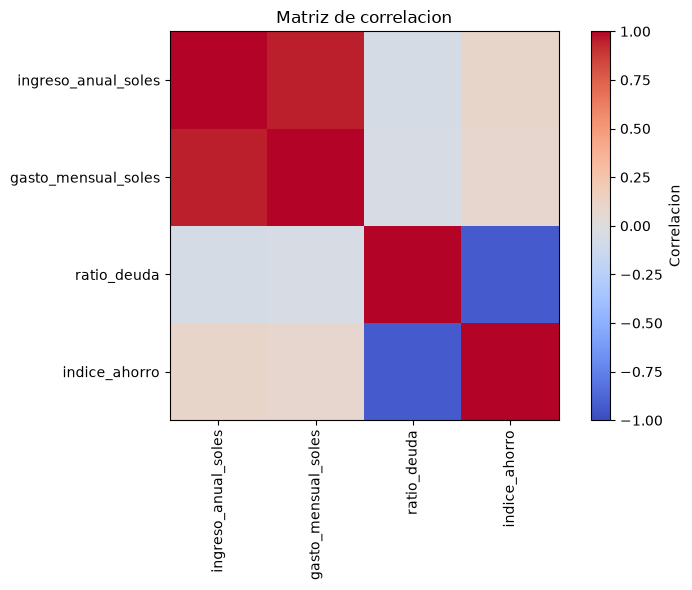

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlacion")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()


In [5]:
num = df.select_dtypes(include="number")

comparacion = pd.DataFrame({
    "min": num.min(),
    "max": num.max(),
    "rango": num.max() - num.min(),
    "std": num.std(),
    "iqr": num.quantile(0.75) - num.quantile(0.25)
}).sort_values("rango", ascending=False)

comparacion

,min,max,rango,std,iqr
ingreso_anual_soles,15000.00,193475.4400,178475.4400,23592.576868,28301.310000
gasto_mensual_soles,634.49,9566.3800,8931.8900,1135.216269,1291.255000
indice_ahorro,0.01,0.9800,0.9700,0.196183,0.279675
ratio_deuda,0.02,0.9425,0.9225,0.175748,0.258550


## Respuestas del Desafío 1

Completen sus respuestas aquí.

**1. Variable que eliminaríamos y justificación:**  
Respuesta: cliente_id. Es un identificador único para cada registro y no aporta ningún patrón de comportamiento predictivo. Si se incluye, el modelo podría intentar memorizar IDs en lugar de generalizar.

**2. Variables categóricas nominales:**  
Respuesta: region. Representa ubicaciones geográficas sin un orden jerárquico o matemático intrínseco.

**3. Variables categóricas ordinales:**  
Respuesta: experiencia_digital y satisfaccion_servicio. Tienen categorías con un orden lógico claro (ej. Muy baja < Baja < Media < Alta).

**4. Variables numéricas:**  
Respuesta: ingreso_anual_soles, gasto_mensual_soles, ratio_deuda e indice_ahorro

**5. Variables que deberían escalarse:**  
Respuesta: Todas las variables numéricas, debido a que tienen escalas muy diferentes (ej. ingreso_anual_soles llega hasta casi 200,000, mientras que ratio_deuda va de 0 a 1). Modelos basados en distancias (como KNN) se verían muy afectados si no se escalan.

**6. Variables con alta correlación positiva:**  
Respuesta: ingreso_anual_soles y gasto_mensual_soles. A mayor ingreso, el cliente tiende a gastar más.

**7. Variables con correlación negativa:**  
Respuesta: ratio_deuda e indice_ahorro. Mientras más endeudado está el cliente, menor es su capacidad o índice de ahorro.

**8. Decisiones de preprocesamiento:**  
Respuesta: Eliminar cliente_id
- Aplicar OneHotEncoder a region.

- Aplicar OrdinalEncoder a experiencia_digital y satisfaccion_servicio (definiendo explícitamente el orden de las categorías).

- Aplicar StandardScaler a las variables numéricas.

# Definición del preprocesamiento

Deben completar las listas de variables según sus decisiones del Desafío 1.

Sugerencia:

- `cliente_id` probablemente no debería usarse como predictor.
- `region` puede tratarse como categórica nominal.
- `experiencia_digital` y `satisfaccion_servicio` pueden tratarse como ordinales.
- Las variables numéricas pueden escalarse, especialmente para modelos sensibles a distancia o magnitud.

In [6]:
# Definir columnas según el análisis realizado
drop_cols = ["cliente_id"]

num_cols = [
    "ingreso_anual_soles", 
    "gasto_mensual_soles", 
    "ratio_deuda", 
    "indice_ahorro"
]

nom_cols = ["region"]

ord_cols = [
    "experiencia_digital", 
    "satisfaccion_servicio"
]

In [16]:
# orden estricto de las variables ordinales para el OrdinalEncoder

exp_categories = ["Bajo", "Medio", "Alto", "Muy alto"]
sat_categories = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]


preprocessor = ColumnTransformer(
    transformers=[
        ("drop", "drop", drop_cols),
        ("num", StandardScaler(), num_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nom_cols),
        ("ord", OrdinalEncoder(categories=[exp_categories, sat_categories]), ord_cols)
    ],
    remainder="passthrough"
)


preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

# Desafío 2: Comparación de modelos con Cross Validation (5 PUNTOS)

Comparen al menos 2 de los siguientes modelos:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- MLP

Todos deben evaluarse con:

- 5-Fold Cross Validation.
- Las mismas particiones.
- Métricas: Accuracy, Precision macro, Recall macro y F1 macro.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [19]:

X = df.drop(columns=["clase"])
y = df["clase"]


resultados_f1 = {}

print("Iniciando validación cruzada (5 Folds)...\\n")

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    
    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)
    
    
    mean_f1 = cv_results["test_f1_macro"].mean()
    resultados_f1[name] = mean_f1
    
    print(f"{name}:")
    print(f"  - Accuracy Promedio: {cv_results['test_accuracy'].mean():.4f}")
    print(f"  - F1 Macro Promedio: {mean_f1:.4f}\\n")

Iniciando validación cruzada (5 Folds)...\n
Logistic Regression:
  - Accuracy Promedio: 0.7750
  - F1 Macro Promedio: 0.7767\n
KNN:
  - Accuracy Promedio: 0.7175
  - F1 Macro Promedio: 0.7183\n
Decision Tree:
  - Accuracy Promedio: 0.6775
  - F1 Macro Promedio: 0.6768\n
Random Forest:
  - Accuracy Promedio: 0.7538
  - F1 Macro Promedio: 0.7548\n


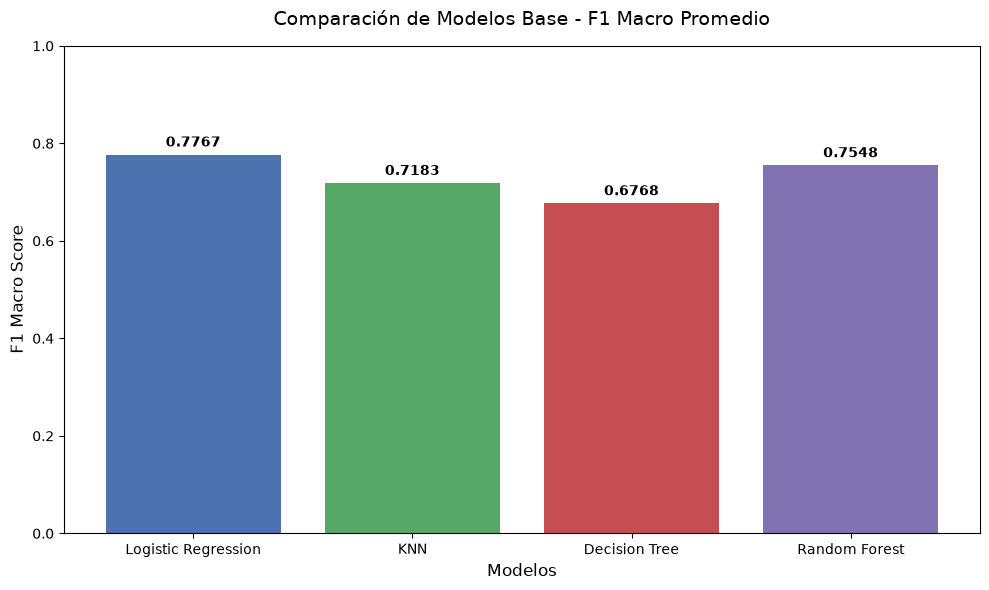

In [21]:

plt.figure(figsize=(10, 6))
bars = plt.bar(resultados_f1.keys(), resultados_f1.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])

plt.title("Comparación de Modelos Base - F1 Macro Promedio", fontsize=14, pad=15)
plt.ylabel("F1 Macro Score", fontsize=12)
plt.xlabel("Modelos", fontsize=12)
plt.ylim(0, 1) 


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Selección del mejor modelo

Completen:

**Mejor modelo elegido:**  
Respuesta: Logistic Regression

**Métrica principal utilizada para elegirlo:**  
Respuesta: F1-score macro

**Justificación:**  
Respuesta: En la validación cruzada (5-folds), la Regresión Logística obtuvo el F1-score macro promedio más alto (0.7767), superando a modelos más complejos como Random Forest. Se eligio esta métrica principal porque asegura un rendimiento equilibrado en la clasificación de las tres clases, evitando que el modelo se sesgue hacia la clase mayoritaria.

# Entrenamiento final del mejor modelo

Una vez elegido el mejor modelo con Cross Validation, entrenen el pipeline final usando todo el conjunto de entrenamiento.   

In [24]:
# Modelo elegido: logistic regression
pipeline_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])


pipeline_final.fit(X, y)
print("Pipeline entrenado con éxito con el dataset de entrenamiento.")

Pipeline entrenado con éxito con el dataset de entrenamiento.


# Desafío 3: Guardar el modelo y crear función de evaluación (5 PUNTOS)

El modelo debe guardarse en disco y luego cargarse desde una función de evaluación.

In [25]:
model_path = "best_model.pkl"
joblib.dump(pipeline_final, model_path)
print(f"Modelo guardado exitosamente en: {model_path}")

Modelo guardado exitosamente en: best_model.pkl


In [29]:
def evaluate(model_path, X_test, y_test=None):
    """
    Carga un modelo previamente almacenado y lo evalúa sobre un conjunto de prueba.
    """
    # 1. Cargar el modelo desde el archivo
    modelo_cargado = joblib.load(model_path)
    
    # 2. Generar predicciones
    y_pred = modelo_cargado.predict(X_test)
    
    # Si tenemos las etiquetas reales, imprimimos un reporte rápido
    if y_test is not None:
        f1 = f1_score(y_test, y_pred, average="macro")
        print(f"F1-score macro en este conjunto: {f1:.4f}")
        
    return y_pred

# Prueba del pipeline con un subconjunto de 20 observaciones

Antes de evaluar todo el conjunto de test, prueben el pipeline con 20 observaciones.

In [30]:
# Cargar el dataset de test
df_test = pd.read_csv("Data/dataset_test.csv")

# Separar en X_test e y_test
X_test = df_test.drop(columns=["clase"])
y_test = df_test["clase"]

In [31]:
X_subset = X_test.sample(20, random_state=42)
y_subset = y_test.loc[X_subset.index]

y_pred_subset = evaluate(model_path, X_subset, y_subset)

pd.DataFrame({
    "Clase real": y_subset.values,
    "Clase predicha": y_pred_subset
})

F1-score macro en este conjunto: 0.5674


,Clase real,Clase predicha
0,Clase_C_alto_riesgo,Clase_C_alto_riesgo
1,Clase_C_alto_riesgo,Clase_B_riesgo_medio
2,Clase_A_bajo_riesgo,Clase_B_riesgo_medio
3,Clase_A_bajo_riesgo,Clase_B_riesgo_medio
4,Clase_C_alto_riesgo,Clase_C_alto_riesgo
5,Clase_C_alto_riesgo,Clase_C_alto_riesgo
6,Clase_C_alto_riesgo,Clase_C_alto_riesgo
7,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo
8,Clase_A_bajo_riesgo,Clase_B_riesgo_medio
9,Clase_A_bajo_riesgo,Clase_A_bajo_riesgo


# Desafío 4: Evaluación final en conjunto de test (5 PUNTOS)

Este es el resultado final del laboratorio.

Deben evaluar el modelo guardado sobre todo el conjunto de test y reportar las métricas finales.

Importante:

- El conjunto de test no debe usarse para seleccionar modelos.
- Solo debe utilizarse al final.
- El resultado principal para la competencia será el **F1-score macro**.

In [ ]:
# TODO: Evaluación final sobre todo el conjunto de test

y_pred_test = evaluate(model_path, X_test, y_test)

In [ ]:
# TODO: Guardar predicciones finales

final_results = X_test.copy()
final_results["Clase real"] = y_test.values
final_results["Clase predicha"] = y_pred_test

final_results.to_csv("resultados_test.csv", index=False)
final_results.head()

# Desafío 5: Entrena tu mejor modelo
## Este desafío tiene nota doble y aparte. (20 PUNTOS)

Explora con [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) los parámetros de los modelos (MLP, ensambles, regresión logística, etc) y encuentre el **MEJOR** modelo aplicando el código anteriormente desarrollado.

Al final el mejor modelo deberá ser probado en el conjunto de test.

# Regla de calificación por desempeño

La nota máxima de desempeño será **20** y se asignará al grupo que obtenga el mejor resultado en el conjunto de test, usando como métrica principal:

## F1-score macro

Los demás grupos serán calificados en función de la distancia entre su resultado y el mejor resultado obtenido en la clase.

Una posible regla de asignación es:

```python
nota_grupo = 20 * (f1_grupo / f1_mejor)
```

Por ejemplo, si el mejor grupo obtiene `F1 = 0.90` y otro grupo obtiene `F1 = 0.81`, entonces:

```python
nota = 20 * (0.81 / 0.90) = 18
```

## Penalización por resultados idénticos

Si todos los grupos presentan exactamente los mismos resultados, se aplicará una penalización de **-5 puntos a todos los grupos**, debido a que esto sugiere copia o falta de exploración experimental.

Para evitar esto, cada grupo debe justificar sus decisiones y explorar al menos una variante propia del pipeline o del modelo.

# Entregables

Al finalizar el laboratorio, cada grupo deberá entregar:

1. Notebook completamente ejecutado.
2. Archivo `best_model.pkl`.
3. Archivo `resultados_test.csv`.
4. Gráfico comparativo de modelos.
5. Respuestas a desafíos.
6. F1-score macro final obtenido sobre el conjunto de test.